# HDT 4: Regresión Logística y Métricas

**Ciencia de Datos, Sección A** · Asignada: jueves 17 de septiembre · **Entrega: martes 22 de septiembre, 23:59**

**Nombre:** Milton Beltran

Completar las celdas marcadas con `# ¿Qué va aquí?`. Cada ejercicio incluye una verificación comentada: descomentar para comprobar el resultado. Antes de entregar: **Kernel → Restart & Run All** (un notebook que no corre de arriba a abajo pierde 0.5 pts).

AI: resolver sin AI. Si se usó para entender un concepto, anotarlo en la bitácora del final (no penaliza).

## Setup

Dependencias: `pip install numpy pandas matplotlib scikit-learn`. Todo es determinista (semilla fija y split fijo): las verificaciones son exactas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AZUL, ROJO, GRIS, LINEA = "#3A6EA5", "#B04A2E", "#75808E", "#E0E4EA"

def eje_limpio(ax):
    ax.grid(color=LINEA, lw=0.6, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

## Los datos

Una empresa de internet residencial quiere saber qué clientes van a cancelar. Historial de 1,200 clientes: `mensualidad` (quetzales al mes), `meses` (antigüedad como cliente), `reclamos` (en el último año) y `cancelo` (1 = canceló el servicio). Es el mismo tipo de problema que la mora de la sesión 14, con otro negocio.

La celda genera los datos completa; no hay nada que llenar aquí.

In [2]:
rng = np.random.default_rng(9)
n = 1200
mensualidad = rng.normal(350, 90, n).clip(150, 700).round(0)
meses = rng.integers(1, 61, n)
reclamos = np.minimum(rng.poisson(0.8, n), 6)

riesgo = -1.1 + 0.006 * (mensualidad - 350) - 0.06 * meses + 0.9 * reclamos
cancelo = (rng.random(n) < 1 / (1 + np.exp(-riesgo))).astype(int)

df = pd.DataFrame({"mensualidad": mensualidad, "meses": meses,
                   "reclamos": reclamos, "cancelo": cancelo})
print("clientes:", len(df), "| fracción que canceló:", df["cancelo"].mean().round(3))
df.head()

clientes: 1200 | fracción que canceló: 0.169


,mensualidad,meses,reclamos,cancelo
0,278.0,48,0,0
1,372.0,46,0,0
2,201.0,7,0,0
3,409.0,24,2,0
4,453.0,48,3,0


## Parte A · El modelo (0.5 pt)

Regresión logística como en la sesión 14: una suma con pesos que la sigmoide convierte en una probabilidad entre 0 y 1.

### Ejercicio 1 (0.15): entrenar y leer los pesos

Entrenar el pipeline de clase (StandardScaler + LogisticRegression) sobre el split dado. Extraer el punto de partida `b` y los tres `pesos`, e imprimirlos con el nombre de su columna. Responder en un comentario: ¿qué columna protege más contra la cancelación?

In [3]:
from pandas import col
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

columnas = ["mensualidad", "meses", "reclamos"]
X_train, X_test, y_train, y_test = train_test_split(
    df[columnas], df["cancelo"], test_size=0.3, random_state=42)

modelo = Pipeline([("escala", StandardScaler()), ("logit", LogisticRegression())]).fit(X_train, y_train)
b = modelo[1].intercept_[0]  
pesos = modelo[1].coef_[0]  

# imprimir b y cada peso con su columna
print(f"b: {b:.2f}")
for colmn, w in zip(columnas, pesos):
    print(f"{colmn:12s}: {w:.2f}")

# Verificación (descomentar):
assert round(b, 2) == -2.29
assert [round(w, 2) for w in pesos] == [0.64, -1.35, 0.62]

b: -2.29
mensualidad : 0.64
meses       : -1.35
reclamos    : 0.62


La columna que mas protege es la de meses, ya que a diferencia de las otras tiene un peso negativo. 

### Ejercicio 2 (0.20): un cliente, a mano

Cliente nuevo: paga Q380, lleva 4 meses, puso 2 reclamos. Calcular su probabilidad de cancelar sin `predict_proba`: (a) escalar cada valor con `escalador.mean_` y `escalador.scale_`, (b) armar la suma `b + w1 * x1 + w2 * x2 + w3 * x3`, (c) pasarla por la sigmoide. Luego comparar contra `modelo.predict_proba`: deben coincidir.

In [4]:
def sigmoide(z):
    return 1 / (1 + np.exp(-z))

cliente = pd.DataFrame({"mensualidad": [380.0], "meses": [4], "reclamos": [2]})

# el escalador es modelo[0]; sus medias y desviaciones: .mean_ y .scale_
z = b + modelo[0].transform(cliente)[0].dot(pesos)          # ¿Qué va aquí? escalar el cliente y sumar con los pesos
p_mano = sigmoide(z)
p_sklearn = modelo.predict_proba(cliente)[0, 1]  # con modelo.predict_proba(cliente)


print(f"z = {z:.3f}")
print(f"a mano: {p_mano:.3f} | sklearn: {p_sklearn:.3f}")
# Verificación (descomentar):
assert round(p_mano, 3) == round(p_sklearn, 3) == 0.721

z = 0.949
a mano: 0.721 | sklearn: 0.721


### Ejercicio 3 (0.15): equivocarse con confianza cuesta caro

El castigo de una predicción es `-log(p asignada a lo que realmente pasó)`. (a) Calcular el castigo para un cliente que sí canceló al que el modelo le dijo 0.99, 0.9, 0.5, 0.1 y 0.01. (b) Con `log_loss`, el castigo promedio del modelo en test contra el de un modelo tibio que le dice 0.5 a todo el mundo.

In [5]:
from sklearn.metrics import log_loss

p_dijo = np.array([0.99, 0.9, 0.5, 0.1, 0.01])
castigos = -np.log(p_dijo)   # ¿Qué va aquí?

prob = modelo.predict_proba(X_test)[:, 1]       # las probabilidades del test, con modelo.predict_proba
castigo_modelo = log_loss(y_test, prob)  # ¿Qué va aquí? log_loss de y_test y prob
castigo_tibio = log_loss(y_test, np.full(len(y_test), 0.5))  # contra np.full(len(y_test), 0.5)

for p,c in zip(p_dijo, castigos):
    print(f"p = {p:.2f} | castigo = {c:.3f}")

print(f"castigo del modelo: {castigo_modelo:.3f} | modelo tibio: {castigo_tibio:.3f}")
# Verificación (descomentar):
assert round(castigos[-1], 1) == 4.6
assert round(castigo_modelo, 3) == 0.347 and round(castigo_tibio, 3) == 0.693

p = 0.99 | castigo = 0.010
p = 0.90 | castigo = 0.105
p = 0.50 | castigo = 0.693
p = 0.10 | castigo = 2.303
p = 0.01 | castigo = 4.605
castigo del modelo: 0.347 | modelo tibio: 0.693


## Parte B · Métricas como conteos (0.5 pt)

Solo el 17% de los clientes cancela. Con clases desbalanceadas, contar aciertos engaña; contar por tipo de acierto y de error, no.

### Ejercicio 4 (0.15): el modelo perezoso

(a) La accuracy de un modelo perezoso que dice "nadie cancela". (b) La accuracy del modelo real con umbral 0.5. Ver qué tan poca ventaja aparenta tener el modelo cuando se mide con la métrica equivocada.

In [6]:
pred = (prob >= 0.5).astype(int)  # ¿Qué va aquí? las predicciones con umbral 0.5

acc_perezoso = (y_test == 0).mean()  # ¿Qué va aquí? fracción de y_test que es 0
acc_modelo = (pred == y_test).mean()  # ¿Qué va aquí? fracción de aciertos del modelo

print(f"accuracy perezoso: {acc_perezoso:.3f} | modelo: {acc_modelo:.3f}")

# Verificación (descomentar):
assert round(acc_perezoso, 3) == 0.833
assert round(acc_modelo, 3) == 0.869

accuracy perezoso: 0.833 | modelo: 0.869


### Ejercicio 5 (0.20): los cuatro conteos

Con umbral 0.5, calcular los cuatro conteos y armar la tabla 2 x 2 como en clase (filas: canceló / se quedó; columnas: el modelo dijo cancela / dijo se queda).

In [7]:
TP = ((pred == 1) & (y_test == 1)).sum()   
FP = ((pred == 1) & (y_test == 0)).sum()   
FN = ((pred == 0) & (y_test == 1)).sum()  
TN = ((pred == 0) & (y_test == 0)).sum()  

tabla = pd.DataFrame([[TP, FN], [FP, TN]], index=['Cancelado', 'Se ha quedao'], columns=['dijo cancela', 'dijo se queda'])



# Verificación (descomentar):
assert [TP, FP, FN, TN] == [22, 9, 38, 291]
assert TP + FP + FN + TN == len(y_test)

tabla

,dijo cancela,dijo se queda
Cancelado,22,38
Se ha quedao,9,291


### Ejercicio 6 (0.15): las dos preguntas del negocio

Desde los conteos, sin sklearn: precision (de las alertas, ¿cuántas eran canceladores de verdad?) y recall (de los que cancelaron, ¿a cuántos alcanzó a avisar el modelo?). Imprimir las dos frases completas con sus números, como en la sesión 14.

In [8]:
precision = TP / (TP + FP) 
recall = TP / (TP + FN)   

# imprimir: "alertas: ..., de ellas canceladores: ...  -> precision = ..."
#           "canceladores reales: ..., avisados: ...   -> recall = ..."

print(f"alertas: {TP + FP},canceladores: {TP}  -> precision = {precision:.2f}")
print(f"canceladores reales: {TP + FN}, avisados: {TP}   -> recall = {recall:.2f}")
# Verificación (descomentar):
assert round(precision, 2) == 0.71
assert round(recall, 2) == 0.37

alertas: 31,canceladores: 22  -> precision = 0.71
canceladores reales: 60, avisados: 22   -> recall = 0.37


## Parte C · Umbral, AUC y calibración (0.8 pt)

El 0.5 es un default, no una decisión. Y dos preguntas más profundas que cualquier umbral: ¿el modelo ordena bien?, ¿dice la verdad?

### Ejercicio 7 (0.20): mover el umbral

Para cada umbral en [0.2, 0.35, 0.5, 0.65]: recalcular predicciones, contar alertas, precision y recall, imprimir la línea y guardar el número de alertas en `alertas_por_umbral`. Esta tabla es el insumo de la parte D.

In [9]:
alertas_por_umbral = []
for umbral in [0.2, 0.35, 0.5, 0.65]:
    pred_u = (prob >= umbral).astype(int)  # ¿Qué va aquí? las predicciones con el umbral actual
    TP = ((pred_u == 1) & (y_test == 1)).sum()   
    FP = ((pred_u == 1) & (y_test == 0)).sum()   
    FN = ((pred_u == 0) & (y_test == 1)).sum()  
    TN = ((pred_u == 0) & (y_test == 0)).sum()

    alertas=TP + FP
    precision_u = TP / alertas
    recall_u = TP / (TP + FN)
    print(f"umbral: {umbral:.2f} | alertas: {TP + FP}, canceladores: {TP}  -> precision = {precision_u:.2f}")
    alertas_por_umbral.append(alertas)



# Verificación (descomentar):
assert alertas_por_umbral == [116, 63, 31, 12]

umbral: 0.20 | alertas: 116, canceladores: 43  -> precision = 0.37
umbral: 0.35 | alertas: 63, canceladores: 32  -> precision = 0.51
umbral: 0.50 | alertas: 31, canceladores: 22  -> precision = 0.71
umbral: 0.65 | alertas: 12, canceladores: 8  -> precision = 0.67


### Ejercicio 8 (0.20): la curva completa

La misma idea, continua: para umbrales de 0.05 a 0.90 en pasos de 0.05, graficar precision (AZUL) y recall (ROJO) contra el umbral, con `eje_limpio`, leyenda y una línea vertical punteada en 0.5. Un vistazo a la figura debe bastar para ver el intercambio.

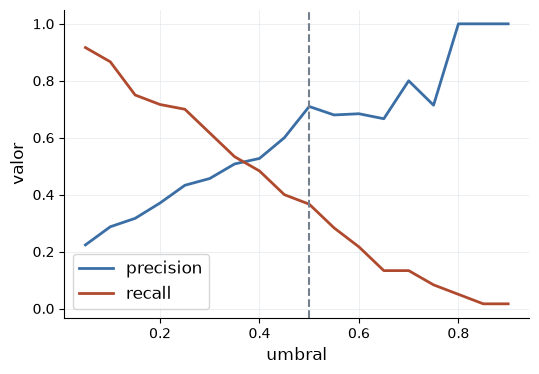

In [10]:
umbrales = np.arange(0.05, 0.91, 0.05)
precisiones = []
recalls = []

# ¿Qué va aquí? llenar las listas y graficar
precisiones = []
recalls = []
for umbral in umbrales:
    pred_u = (prob >= umbral).astype(int)
    TP = ((pred_u == 1) & (y_test == 1)).sum()   
    FP = ((pred_u == 1) & (y_test == 0)).sum()   
    FN = ((pred_u == 0) & (y_test == 1)).sum()  
    TN = ((pred_u == 0) & (y_test == 0)).sum()
    
    precision_u = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall_u = TP / (TP + FN) if (TP + FN) > 0 else 0
    
    precisiones.append(precision_u)
    recalls.append(recall_u)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(umbrales, precisiones, color=AZUL, lw=2, label="precision")
ax.plot(umbrales, recalls, color=ROJO, lw=2, label="recall")
ax.axvline(0.5, color=GRIS, ls="--")
ax.legend(fontsize=12)
ax.set_xlabel("umbral", fontsize=12)
ax.set_ylabel("valor", fontsize=12)
eje_limpio(ax) 
# Verificación (descomentar):
assert len(precisiones) == len(recalls) == len(umbrales) == 18

### Ejercicio 9 (0.20): AUC por pares

AUC sin fórmula, como en la sesión: tomar 5,000 canceladores al azar y 5,000 no canceladores al azar (con `rng_auc.choice`, en ese orden), y medir en qué fracción de los pares el cancelador recibió mayor probabilidad. Comparar contra `roc_auc_score`.

In [11]:
from sklearn.metrics import roc_auc_score

rng_auc = np.random.default_rng(7)

pos = prob[y_test == 1]   #  probabilidades de los que cancelaron
neg = prob[y_test == 0]   # probabilidades de los que se quedaron
# luego, exactamente en este orden:
p_azar = rng_auc.choice(pos, 5000)
n_azar = rng_auc.choice(neg, 5000)
auc_pares = (p_azar > n_azar).mean()     # fracción de pares donde el cancelador tuvo mayor probabilidad
auc_sklearn = roc_auc_score(y_test, prob)

print(f"auc_pares: {auc_pares:.3f} | auc_sklearn: {auc_sklearn:.3f}")
print(f"Canceladores: {len(pos)} | Se han quedao: {len(neg)}")
# Verificación (descomentar):
assert round(auc_pares, 3) == 0.821
assert round(auc_sklearn, 3) == 0.822

auc_pares: 0.821 | auc_sklearn: 0.822
Canceladores: 60 | Se han quedao: 300


### Ejercicio 10 (0.20): ¿dice la verdad?

Agrupar las probabilidades del test en cajones con `pd.cut` (bordes [0, 0.2, 0.4, 0.6, 0.8, 1.0]) y construir la tabla de calibración: por cajón, el promedio de lo que el modelo dijo, la fracción que de verdad canceló y el número de clientes.

In [12]:
grupos = pd.cut(prob, [0, 0.2, 0.4, 0.6, 0.8, 1.0])

calib = pd.DataFrame({"dijo": prob, "real": y_test.values}).groupby(grupos).agg(dijo=("dijo", "mean"), clientes=("real", "count"), real=("real", "mean"))

# Verificación (descomentar):
assert calib["clientes"].tolist() == [244, 61, 36, 16, 3]

calib.round(2)

,dijo,clientes,real
"(0.0, 0.2]",0.07,244,0.07
"(0.2, 0.4]",0.29,61,0.23
"(0.4, 0.6]",0.48,36,0.44
"(0.6, 0.8]",0.69,16,0.62
"(0.8, 1.0]",0.85,3,1.00


## Parte D · Criterio (0.2 pt)

### Ejercicio 11 (0.20)

Dos preguntas, 2-3 líneas cada una, **citando los números obtenidos**:


In [13]:
filas = []
for umbral in [0.2, 0.35, 0.5, 0.65]:
    pred_u = (prob >= umbral).astype(int)
    alertas = (pred_u == 1).sum()
    fn = ((pred_u == 0) & (y_test == 1)).sum()
    filas.append({"umbral": umbral, "alertas": alertas, "perdidos (FN)": fn,
                  "costo llamadas": 25 * alertas, "costo perdidos": 1500 * fn})

costos = pd.DataFrame(filas)
costos["costo total"] = costos["costo llamadas"] + costos["costo perdidos"]
costos

,umbral,alertas,perdidos (FN),costo llamadas,costo perdidos,costo total
0,0.20,116,17,2900,25500,28400
1,0.35,63,28,1575,42000,43575
2,0.50,31,38,775,57000,57775
3,0.65,12,52,300,78000,78300


**(a)** Una llamada de retención cuesta Q25; un cliente que se va sin aviso cuesta Q1,500. Con la tabla del ejercicio 7, ¿qué umbral conviene y por qué? (Basta comparar el costo total de dos o tres umbrales.)

**(b)** El gerente quiere presentar el modelo diciendo "acierta el 87% de las veces". Con los números de los ejercicios 4 y 6, explicar por qué ese argumento es débil y proponer el argumento honesto.



**Respuesta (a):** 
Conviene el umbral 0.2. Con los costos reales, el 0.2 cuesta Q28,400 contra Q57,775 del 0.5 por defecto, es decir, la mitad. Es cierto que lanza 116 alertas en vez de 31, y 73 de ellas son llamadas desperdiciadas (precision 0.37). Pero cada llamada cuesta Q25, mientras que cada cliente perdido sin aviso cuesta Q1,500. Bajar el umbral reduce los perdidos de 38 a 17ahorrando Q31,500, muy superior a los Q2,125 extra en llamadas. 


**Respuesta (b):** El "87 %" es un dato engañoso. Un modelo que dice "nadie cancela" ya acierta el 83.3 %, así que el modelo solo gana 3.6 puntos. Además, de los 60 clientes que cancelaron, solo avisó a 22 (recall 0.37). El argumento honesto: "7 de cada 10 alertas son reales (precision 0.71) y el modelo ordena bien el riesgo (AUC 0.82), pero con umbral 0.5 solo detecta a 37 de cada 100 que se van. Bajando el umbral detectaríamos más."

## Bitácora de AI (opcional, no penaliza)

Si se usó AI para entender algún concepto, anotar aquí qué se preguntó y qué se entendió. Si no se usó, escribir "No se usó".

- **Ejercicio 1:** usé AI (Claude) para resolver un bug. Al armar el pipeline mezclé dos sintaxis: le pasé a `make_pipeline` una lista de tuplas `(nombre, paso)`, que es el formato de `Pipeline`. Salía `TypeError: Last step of Pipeline should implement fit...`. Entendí que `make_pipeline` recibe los pasos sueltos y les pone nombre solo, mientras que `Pipeline` recibe la lista de tuplas con nombres propios.
- **Ejercicio 2:** usé AI (Claude) para resolver un bug. `modelo[0].transform(cliente)` y `modelo.predict_proba(cliente)[:, 1]` devuelven arrays de un elemento (una fila por cliente), y el `assert` fallaba con `TypeError: type numpy.ndarray doesn't define __round__ method`. Entendí que hay que sacar el valor de la fila: `transform(cliente)[0]` y `predict_proba(cliente)[0, 1]` (fila 0, columna 1) devuelven números sueltos que `round()` sí acepta.
- **Ejercicio 5:** usé AI (Claude) para corregir la tabla 2 × 2. Los conteos estaban bien, pero armé la tabla en el orden predeterminado (`[[TN, FP], [FN, TP]]`, con etiquetas `Negativo`/`Positivo`) y no con el correcto para este ejercicioi. Me ayudó a darme cuenta del orden correcto `[[TP, FN], [FP, TN]]` y las etiquetas de filas (realidad). También entendí que el notebook solo muestra la última expresión de la celda, así que `tabla` tiene que ir después de los `assert` para que se vea.
- **Ejercicio 7:** usé AI (Claude) para resolver un bug. Las líneas del `append`, la precision y el `print` quedaron fuera del `for` por la indentación, así que solo corrían una vez con el último umbral. Además dividía `TP / alertas_por_umbral` (la lista completa) en vez de entre las alertas de esa vuelta, lo que daba un array y el `print` fallaba con `TypeError: unsupported format string passed to numpy.ndarray.__format__`. Entendí que todo lo que se calcula por umbral tiene que ir indentado dentro del `for`, y que la precision se divide entre `TP + FP` de ese umbral.
- **Ejercicio 10:** usé AI (Claude) para resolver un bug. Tenía `groupby("grupos")` con comillas, y pandas buscaba una columna llamada "grupos" que no existía (`KeyError: 'grupos'`); `grupos` es la variable creada con `pd.cut`, así que va sin comillas. También había puesto `grupos` en la columna "dijo" en vez de `prob`, y usaba `agg({"real": ["mean", "count"]})`, que no crea la columna `clientes`. Entendí la agregación con nombre: `agg(dijo=("dijo", "mean"), real=("real", "mean"), clientes=("real", "count"))`.